# MVP v0.2.5.2: Trajectory MSE — Real vs Synthetic State Comparison

**Date:** 2026-03-13  
**Builds on:** MVP v0.2.5 (reward model fix, target+expert diffuser)

## Goal

Directly measure how similar the chunk diffusion model's synthetic trajectories are
to the target policy's real trajectories, using per-step and per-dimension MSE.

Run the full guidance sweep from v0.2.5, then compute MSE for each config to see
how guidance affects trajectory similarity.

## Pipeline

1. Load pre-collected target policy rollouts (50 episodes) + expert demos (200 episodes)
2. Chunk all episodes into training data
3. Train chunk diffuser on mixed data (same as v0.2.5)
4. Train BC_Gaussian behavior policy + load target scorer
5. Guided stitching sweep (same configs as v0.2.5)
6. Compute MSE between real and synthetic trajectories per guidance config
7. Visualizations: MSE vs guidance, per-step error, per-dim error, trajectory overlays

In [1]:
%matplotlib inline
import sys, os
import importlib
import numpy as np
import torch
import torch.nn as nn
import h5py
import json
import math
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict
from copy import deepcopy
from tqdm import tqdm
import time

# Project root
PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

# SOPE imports
from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning

# Robomimic imports
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

# Our imports
import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
CKPT_DIR = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models/test/20260309132349"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
DIFFUSION_SAVE_DIR.mkdir(parents=True, exist_ok=True)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


## Configuration

In [2]:
# ── Obs keys (sorted, matching robomimic convention & LowDimConcatEncoder layout) ──
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# Full dims
STATE_DIM = 19   # object(10) + eef_pos(3) + eef_quat(4) + gripper_qpos(2)
ACTION_DIM = 7   # full robomimic action space
TRANSITION_DIM = STATE_DIM + ACTION_DIM  # 26

# ── Target rollouts ──
NUM_TARGET_ROLLOUTS = 50   # pre-collected from March 9

# ── Chunk config ──
CHUNK_SIZE = 4
FRAME_STACK = 1
STRIDE = 2

# ── Diffusion config (same architecture as v0.2.5) ──
N_DIFFUSION_STEPS = 256
DIM_MULTS = (1, 4, 8)
BASE_DIM = 32
ACTION_WEIGHT = 5.0
PREDICT_EPSILON = False

# ── Training config ──
TRAIN_EPOCHS = 50
BATCH_SIZE = 64
LR = 3e-4
GRAD_CLIP = 1.0

# ── Oracle config ──
ORACLE_JSON = CKPT_DIR / "oracle_50.json"

# ── Trajectory generation config ──
NUM_SYNTHETIC_TRAJS = 50
T_GEN = 60
GAMMA = 1.0

# ── Reward ──
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

# ── Guidance config (matching SOPE diffusion policy config) ──
K_GUIDE = 1
NORMALIZE_GRAD = True
USE_ADAPTIVE = False
CLAMP = False
L_INF = 1.0

GUIDANCE_CONFIGS = [
    {"action_scale": 0.0,  "ratio": 0.0,  "label": "unguided"},
    {"action_scale": 0.05, "ratio": 0.0,  "label": "pos_only_0.05"},
    {"action_scale": 0.1,  "ratio": 0.0,  "label": "pos_only_0.1"},
    {"action_scale": 0.2,  "ratio": 0.0,  "label": "pos_only_0.2"},
    {"action_scale": 0.05, "ratio": 0.25, "label": "full_0.05_r0.25"},
    {"action_scale": 0.1,  "ratio": 0.25, "label": "full_0.1_r0.25"},
    {"action_scale": 0.2,  "ratio": 0.25, "label": "full_0.2_r0.25"},
    {"action_scale": 0.2,  "ratio": 0.5,  "label": "full_0.2_r0.5"},
    {"action_scale": 0.5,  "ratio": 0.25, "label": "full_0.5_r0.25"},
    {"action_scale": 0.5,  "ratio": 0.5,  "label": "full_0.5_r0.5"},
]

# ── Latent vector layout ──
DIM_NAMES = {
    0: "cube_x", 1: "cube_y", 2: "cube_z",
    3: "cube_qx", 4: "cube_qy", 5: "cube_qz", 6: "cube_qw",
    7: "grip2cube_x", 8: "grip2cube_y", 9: "grip2cube_z",
    10: "eef_x", 11: "eef_y", 12: "eef_z",
    13: "eef_qx", 14: "eef_qy", 15: "eef_qz", 16: "eef_qw",
    17: "gripper_q0", 18: "gripper_q1",
}

print(f"state_dim={STATE_DIM}, action_dim={ACTION_DIM}, transition_dim={TRANSITION_DIM}")
print(f"k_guide={K_GUIDE}, adaptive={USE_ADAPTIVE}, clamp={CLAMP}")
print(f"Target rollouts: {NUM_TARGET_ROLLOUTS}, Train epochs: {TRAIN_EPOCHS}")
print(f"Guidance configs to sweep: {len(GUIDANCE_CONFIGS)}")

state_dim=19, action_dim=7, transition_dim=26
k_guide=1, adaptive=False, clamp=False
Target rollouts: 50, Train epochs: 50
Guidance configs to sweep: 10


## Step 1: Load Oracle + Target Rollouts + Expert Demos

In [3]:
# ── Oracle ──
with open(ORACLE_JSON, "r") as f:
    oracle_data = json.load(f)
oracle_returns = np.array(oracle_data["returns"])
oracle_value = float(oracle_data["mean_return"])
oracle_success_rate = float(np.mean(oracle_returns > 0.5))
print(f"Oracle V^pi = {oracle_value:.4f} +/- {np.std(oracle_returns):.4f}")
print(f"Oracle SR = {oracle_success_rate*100:.1f}%")

# ── Load checkpoint ──
ckpt = load_checkpoint(CKPT_DIR, ckpt_path=Path("last.pth"))

# ── Part A: Load target policy rollouts (50 episodes from .h5 files) ──
target_data = []
all_states_list = []
all_actions_list = []

rollout_paths = sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:NUM_TARGET_ROLLOUTS]
assert len(rollout_paths) >= NUM_TARGET_ROLLOUTS, \
    f"Expected {NUM_TARGET_ROLLOUTS} rollouts in {TARGET_ROLLOUT_DIR}, found {len(rollout_paths)}"

for path in tqdm(rollout_paths, desc="Loading target rollouts"):
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
        rewards = f["rewards"][:] if "rewards" in f else np.zeros(len(actions))
    
    if latents.ndim == 3:
        states = latents[:, -1, :]
    else:
        states = latents
    
    states = states.astype(np.float32)
    actions = actions.astype(np.float32)
    
    episode = {
        "states": states[:-1],
        "actions": actions[:-1],
        "rewards": rewards[:-1] if len(rewards) > 1 else rewards,
        "next-states": states[1:],
    }
    target_data.append(episode)
    all_states_list.append(states)
    all_actions_list.append(actions)

print(f"Loaded {len(target_data)} target policy episodes")

# ── Part B: Load expert demos (200 episodes from HDF5) ──
expert_data = []
with h5py.File(DEMO_HDF5, "r") as f:
    demo_keys = sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1]))
    for dk in tqdm(demo_keys, desc="Loading expert demos"):
        demo = f[f"data/{dk}"]
        obs_arrays = [demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS]
        states = np.concatenate(obs_arrays, axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        rewards = demo["rewards"][:].astype(np.float32)
        
        episode = {
            "states": states[:-1],
            "actions": actions[:-1],
            "rewards": rewards[:-1],
            "next-states": states[1:],
        }
        expert_data.append(episode)
        all_states_list.append(states)
        all_actions_list.append(actions)

print(f"Loaded {len(expert_data)} expert demo episodes")

# ── Combine all data for normalization ──
all_episodes = target_data + expert_data
all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
total_transitions = sum(len(ep["states"]) for ep in all_episodes)

norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

target_successes = [np.any(ep["states"][:, CUBE_Z_INDEX] > LIFT_THRESHOLD) for ep in target_data]
target_sr = np.mean(target_successes)
expert_successes = [np.any(ep["states"][:, CUBE_Z_INDEX] > LIFT_THRESHOLD) for ep in expert_data]
expert_sr = np.mean(expert_successes)

print(f"\nCombined: {len(all_episodes)} episodes ({len(target_data)} target + {len(expert_data)} expert), {total_transitions} transitions")
print(f"Target policy SR: {target_sr*100:.1f}%, Expert SR: {expert_sr*100:.1f}%")

Oracle V^pi = 0.5400 +/- 0.4984
Oracle SR = 54.0%


Loading target rollouts:   0%|          | 0/50 [00:00<?, ?it/s]

Loading target rollouts:  70%|███████   | 35/50 [00:00<00:00, 344.54it/s]

Loading target rollouts: 100%|██████████| 50/50 [00:00<00:00, 352.48it/s]

Loaded 50 target policy episodes


...

Loading expert demos:  58%|█████▊    | 117/200 [00:00<00:00, 179.76it/s]

Loading expert demos:  73%|███████▎  | 146/200 [00:00<00:00, 207.66it/s]

Loading expert demos:  86%|████████▌ | 171/200 [00:00<00:00, 218.65it/s]

Loading expert demos: 100%|██████████| 200/200 [00:00<00:00, 220.79it/s]

Loaded 200 expert demo episodes

Combined: 250 episodes (50 target + 200 expert), 12091 transitions
Target policy SR: 0.0%, Expert SR: 100.0%


## Step 2: Chunk Data for Diffusion Training

In [4]:
# Chunk ALL episodes (target + expert) into training data
chunks_states_from = []
chunks_actions_from = []
chunks_states_to = []
chunks_actions_to = []

for ep in all_episodes:
    states = ep["states"]   # (T, 19)
    actions = ep["actions"]  # (T, 7)
    T = len(states)
    
    if T < CHUNK_SIZE + 1:
        continue
    
    for t0 in range(0, T - CHUNK_SIZE, STRIDE):
        s_to = states[t0 : t0 + CHUNK_SIZE + 1]  # (5, 19)
        a_to = actions[t0 : t0 + CHUNK_SIZE]      # (4, 7)
        
        if t0 > 0:
            s_from = states[t0 - 1 : t0].reshape(1, STATE_DIM)
            a_from = actions[t0 - 1 : t0].reshape(1, ACTION_DIM)
        else:
            s_from = states[0:1].reshape(1, STATE_DIM)
            a_from = actions[0:1].reshape(1, ACTION_DIM)
        
        chunks_states_from.append(s_from)
        chunks_actions_from.append(a_from)
        chunks_states_to.append(s_to)
        chunks_actions_to.append(a_to)

chunks_states_from = np.array(chunks_states_from, dtype=np.float32)
chunks_actions_from = np.array(chunks_actions_from, dtype=np.float32)
chunks_states_to = np.array(chunks_states_to, dtype=np.float32)
chunks_actions_to = np.array(chunks_actions_to, dtype=np.float32)

print(f"Chunked {len(all_episodes)} episodes into {len(chunks_states_to)} training chunks")
print(f"  states_to: {chunks_states_to.shape}, actions_to: {chunks_actions_to.shape}")
print(f"  Batches per epoch: {len(chunks_states_to) // BATCH_SIZE}")

Chunked 250 episodes into 5611 training chunks
  states_to: (5611, 5, 19), actions_to: (5611, 4, 7)
  Batches per epoch: 87


## Step 3: Train Chunk Diffuser

In [5]:
# Build TemporalUnet + GaussianDiffusion
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE,
    transition_dim=TRANSITION_DIM,
    dim=BASE_DIM,
    dim_mults=DIM_MULTS,
    attention=False,
).to(device)

diffusion_model = GaussianDiffusion(
    model=temporal_model,
    horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn,
    unnormalizer=unnormalize_fn,
    predict_epsilon=PREDICT_EPSILON,
    loss_type="l2",
    clip_denoised=False,
    action_weight=ACTION_WEIGHT,
    loss_weights=None,
    loss_discount=1.0,
).to(device)

ema = EMA(diffusion_model)
optimizer = torch.optim.Adam(diffusion_model.parameters(), lr=LR)

n_params = sum(p.numel() for p in diffusion_model.parameters())
print(f"Diffusion model: {n_params:,} parameters")

# Prepare training data as tensors
train_x = np.concatenate([
    chunks_states_to[:, :-1, :],  # (N, chunk_size, state_dim)
    chunks_actions_to,             # (N, chunk_size, action_dim)
], axis=-1)  # (N, chunk_size, transition_dim)

train_cond = chunks_states_to[:, 0, :]  # (N, state_dim)

train_x_t = torch.tensor(train_x, dtype=torch.float32, device=device)
train_cond_t = torch.tensor(train_cond, dtype=torch.float32, device=device)

print(f"Training data: x={train_x_t.shape}, cond={train_cond_t.shape}")

/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]


Diffusion model: 3,686,618 parameters
Training data: x=torch.Size([5611, 4, 26]), cond=torch.Size([5611, 19])


In [6]:
# ── Training loop ──
print(f"Training chunk diffuser for {TRAIN_EPOCHS} epochs on {len(train_x_t)} chunks...")
t0_train = time.time()

diffusion_model.train()
epoch_losses = []

for epoch in range(1, TRAIN_EPOCHS + 1):
    perm = torch.randperm(len(train_x_t), device=device)
    ep_loss = []
    
    for start in range(0, len(train_x_t) - BATCH_SIZE + 1, BATCH_SIZE):
        idx = perm[start : start + BATCH_SIZE]
        x_batch = train_x_t[idx]
        c_batch = train_cond_t[idx]
        
        x_norm = normalize_fn(x_batch)
        c_norm = normalize_fn(
            torch.cat([c_batch, torch.zeros(BATCH_SIZE, ACTION_DIM, device=device)], dim=-1)
        )[:, :STATE_DIM]
        
        cond = {0: c_norm}
        loss, _ = diffusion_model.loss(x_norm, cond)
        
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffusion_model.parameters(), GRAD_CLIP)
        optimizer.step()
        ema.update(diffusion_model)
        
        ep_loss.append(loss.item())
    
    mean_loss = np.mean(ep_loss)
    epoch_losses.append(mean_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{TRAIN_EPOCHS}: loss={mean_loss:.6f}")

elapsed_train = time.time() - t0_train
print(f"\nTraining complete: {elapsed_train:.0f}s, final loss: {epoch_losses[-1]:.6f}")

# Save checkpoint
torch.save(diffusion_model.state_dict(), DIFFUSION_SAVE_DIR / "diffusion_model.pt")
torch.save(ema.ema_model.state_dict(), DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt")
print(f"Checkpoint saved to {DIFFUSION_SAVE_DIR}")

Training chunk diffuser for 50 epochs on 5611 chunks...


  Epoch   1/50: loss=0.746616


  Epoch   5/50: loss=0.369834


  Epoch  10/50: loss=0.270287


  Epoch  15/50: loss=0.217744


...

  Epoch  35/50: loss=0.138813


  Epoch  40/50: loss=0.124624


  Epoch  45/50: loss=0.118639


  Epoch  50/50: loss=0.106194

Training complete: 555s, final loss: 0.106194


Checkpoint saved to /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse


## Step 4: Train BC_Gaussian Behavior Policy + Load Target Scorer

In [7]:
class BCGaussian(nn.Module):
    """Simple BC policy with Gaussian output for SOPE-style guidance."""
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_head = nn.Linear(hidden_dim, action_dim)
        self.log_std_head = nn.Linear(hidden_dim, action_dim)
    
    def forward(self, state):
        h = self.net(state)
        mean = self.mean_head(h)
        log_std = self.log_std_head(h).clamp(-5, 2)
        return mean, log_std
    
    def log_prob(self, state, action):
        mean, log_std = self.forward(state)
        std = torch.exp(log_std)
        return -0.5 * (((action - mean) / std) ** 2 + 2 * log_std + math.log(2 * math.pi)).sum(dim=-1)
    
    def grad_log_prob(self, state, action):
        with torch.no_grad():
            mean, log_std = self.forward(state)
            std = torch.exp(log_std)
            return -(action - mean) / (std ** 2)
    
    def grad_log_prob_chunk(self, states, actions):
        B, T, _ = states.shape
        s_flat = states.reshape(B * T, -1)
        a_flat = actions.reshape(B * T, -1)
        grad_flat = self.grad_log_prob(s_flat, a_flat)
        return grad_flat.reshape(B, T, -1)

# Train on target policy rollout data
demo_states = np.concatenate([ep["states"] for ep in target_data], axis=0)
demo_actions = np.concatenate([ep["actions"] for ep in target_data], axis=0)
print(f"Behavior policy training data: {demo_states.shape[0]} (state, action) pairs")

bc_behavior = BCGaussian(STATE_DIM, ACTION_DIM, hidden_dim=256).to(device)
bc_optimizer = torch.optim.Adam(bc_behavior.parameters(), lr=1e-3)

states_t = torch.tensor(demo_states, dtype=torch.float32, device=device)
actions_t = torch.tensor(demo_actions, dtype=torch.float32, device=device)

BC_EPOCHS = 500
BC_BATCH = 256
bc_losses = []

print(f"Training BC_Gaussian behavior policy for {BC_EPOCHS} epochs...")
bc_behavior.train()
for epoch in range(BC_EPOCHS):
    idx = torch.randint(0, len(states_t), (BC_BATCH,), device=device)
    nll = -bc_behavior.log_prob(states_t[idx], actions_t[idx]).mean()
    bc_optimizer.zero_grad()
    nll.backward()
    bc_optimizer.step()
    bc_losses.append(nll.item())

bc_behavior.eval()
print(f"Final NLL: {bc_losses[-1]:.4f}")

# Load target scorer
target_algo = build_algo_from_checkpoint(ckpt, device=str(device))
target_scorer = RobomimicDiffusionScorer(target_algo, device=str(device), obs_keys=OBS_KEYS)
print(f"Target scorer: state_dim={target_scorer.state_dim}, action_dim={target_scorer.action_dim}")

Behavior policy training data: 2625 (state, action) pairs
Training BC_Gaussian behavior policy for 500 epochs...


Final NLL: -6.9045

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['object', 'robot0_eef_quat', 'robot0_eef_pos', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[15:11:26] INFO     build_algo_from_checkpoint took 0.71 seconds to execute                           ]8;id=501456;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=164049;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

Target scorer: state_dim=19, action_dim=7


## Step 5: Guidance Sweep + Trajectory MSE

Run all guidance configs, generate synthetic trajectories from the **same initial states**
as the real target rollouts, and compute paired MSE for each config.

In [8]:
def generate_trajectories_full_guidance(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim,
    chunk_size, t_gen, device,
    target_scorer=None, behavior_scorer=None,
    action_scale=0.0, ratio=0.5,
    k_guide=1, normalize_grad=True,
    use_adaptive=False, clamp=False, l_inf=1.0,
):
    """Generate trajectories with full SOPE-style guidance."""
    guided = (target_scorer is not None and action_scale > 0)
    use_neg_grad = (behavior_scorer is not None and ratio > 0)
    batch_size = initial_states.shape[0]
    transition_dim = state_dim + action_dim
    n_timesteps = diffusion_model.n_timesteps

    padded = torch.cat([initial_states, torch.zeros(batch_size, action_dim, device=device)], dim=1)
    normalized_initial = normalize_fn(padded)[:, :state_dim]

    all_trajectories = torch.zeros(batch_size, t_gen, transition_dim, device=device)
    conditions = {0: normalized_initial}
    total_generated = 0
    n_iterations = 0

    while total_generated < t_gen:
        n_iterations += 1
        shape = (batch_size, chunk_size, transition_dim)
        x = torch.randn(shape, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_diff in reversed(range(n_timesteps)):
            t_tensor = torch.full((batch_size,), t_diff, device=device, dtype=torch.long)
            with torch.no_grad():
                model_mean, _, model_log_variance = diffusion_model.p_mean_variance(x=x, t=t_tensor)
                model_std = torch.exp(0.5 * model_log_variance)

            if guided:
                model_mean = unnormalize_fn(model_mean)
                for _k in range(k_guide):
                    states_chunk = model_mean[:, :, :state_dim]
                    actions_chunk = model_mean[:, :, state_dim:]
                    target_grad = target_scorer.grad_log_prob_chunk(states_chunk, actions_chunk)
                    if use_neg_grad:
                        behavior_grad = behavior_scorer.grad_log_prob_chunk(states_chunk, actions_chunk)
                    if normalize_grad:
                        eps = 1e-6
                        target_grad = target_grad / (target_grad.norm(dim=-1, keepdim=True) + eps)
                        if use_neg_grad:
                            behavior_grad = behavior_grad / (behavior_grad.norm(dim=-1, keepdim=True) + eps)
                    if clamp:
                        target_grad = target_grad.clamp(-l_inf, l_inf)
                        if use_neg_grad:
                            behavior_grad = behavior_grad.clamp(-l_inf, l_inf)
                    if use_neg_grad:
                        guide_actions = target_grad - ratio * behavior_grad
                    else:
                        guide_actions = target_grad
                    guide = torch.zeros_like(model_mean)
                    guide[:, :, state_dim:] = guide_actions
                    guide = action_scale * guide
                    model_mean = model_mean + guide
                    model_mean = normalize_fn(model_mean)
                    model_mean = apply_conditioning(model_mean, conditions, state_dim)
                    model_mean = unnormalize_fn(model_mean)
                model_mean = normalize_fn(model_mean)

            noise = torch.randn_like(x)
            nonzero_mask = (1 - (t_diff == 0) * 1.0)
            x = model_mean + nonzero_mask * model_std * noise
            x = apply_conditioning(x, conditions, state_dim)

        chunk_unnorm = unnormalize_fn(x)
        steps_remaining = t_gen - total_generated
        steps_to_store = min(chunk_size - 1, steps_remaining)
        all_trajectories[:, total_generated:total_generated + steps_to_store] = chunk_unnorm[:, :steps_to_store]
        total_generated += steps_to_store

        if total_generated >= t_gen:
            break
        last_states_norm = x[:, -1, :state_dim]
        conditions = {0: last_states_norm}

    return all_trajectories.detach().cpu().numpy()


# ── Build paired real trajectory array ──
N_COMPARE = min(NUM_SYNTHETIC_TRAJS, len(target_data))
real_trajs = []
for ep in target_data[:N_COMPARE]:
    traj = np.concatenate([ep["states"], ep["actions"]], axis=-1)
    T = len(traj)
    if T >= T_GEN:
        real_trajs.append(traj[:T_GEN])
    else:
        padded = np.zeros((T_GEN, TRANSITION_DIM), dtype=np.float32)
        padded[:T] = traj
        padded[T:] = traj[-1]
        real_trajs.append(padded)
real_trajs = np.array(real_trajs)
real_states = real_trajs[:, :, :STATE_DIM]
real_actions = real_trajs[:, :, STATE_DIM:]

# ── Get initial states from real target rollouts (paired comparison) ──
np.random.seed(42)
torch.manual_seed(42)
real_initial_states = np.array([ep["states"][0] for ep in target_data[:N_COMPARE]])
initial_states_t = torch.tensor(real_initial_states, dtype=torch.float32, device=device)
print(f"Paired comparison: {N_COMPARE} trajectories, {T_GEN} steps each")
print(f"Using real initial states for all configs (same starting points)")

# ── Run guidance sweep ──
results_by_config = {}

for i, gc in enumerate(GUIDANCE_CONFIGS):
    label = gc["label"]
    action_scale = gc["action_scale"]
    ratio = gc["ratio"]
    print(f"\n[{i+1}/{len(GUIDANCE_CONFIGS)}] {label}")

    t0 = time.time()
    trajs = generate_trajectories_full_guidance(
        diffusion_model=ema.ema_model,
        initial_states=initial_states_t,
        normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM, action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
        target_scorer=target_scorer if action_scale > 0 else None,
        behavior_scorer=bc_behavior if (action_scale > 0 and ratio > 0) else None,
        action_scale=action_scale, ratio=ratio,
        k_guide=K_GUIDE, normalize_grad=NORMALIZE_GRAD,
        use_adaptive=USE_ADAPTIVE, clamp=CLAMP, l_inf=L_INF,
    )
    elapsed = time.time() - t0

    synth_states = trajs[:, :, :STATE_DIM]
    synth_actions = trajs[:, :, STATE_DIM:]

    # Verify initial states match
    init_diff = np.abs(real_states[:, 0, :] - synth_states[:, 0, :]).max()

    # Per-step MSE
    per_step_mse = np.mean((real_states - synth_states) ** 2, axis=(0, 2))
    # Per-dim MSE
    per_dim_mse = np.mean((real_states - synth_states) ** 2, axis=(0, 1))
    # Per-traj MSE
    per_traj_mse = np.mean((real_states - synth_states) ** 2, axis=(1, 2))
    # Aggregate
    total_state_mse = np.mean((real_states - synth_states) ** 2)
    total_action_mse = np.mean((real_actions - synth_actions) ** 2)

    # Success rates
    synth_sr = np.mean([np.any(synth_states[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD) for j in range(N_COMPARE)])
    real_sr_val = np.mean([np.any(real_states[j, :, CUBE_Z_INDEX] > LIFT_THRESHOLD) for j in range(N_COMPARE)])

    results_by_config[label] = {
        "trajs": trajs,
        "synth_states": synth_states,
        "synth_actions": synth_actions,
        "per_step_mse": per_step_mse,
        "per_dim_mse": per_dim_mse,
        "per_traj_mse": per_traj_mse,
        "state_mse": total_state_mse,
        "action_mse": total_action_mse,
        "state_rmse": np.sqrt(total_state_mse),
        "synth_sr": synth_sr,
        "real_sr": real_sr_val,
        "init_diff": init_diff,
        "time": elapsed,
        "action_scale": action_scale,
        "ratio": ratio,
    }

    print(f"  State MSE={total_state_mse:.6f}, RMSE={np.sqrt(total_state_mse):.6f}, "
          f"SR={synth_sr*100:.1f}% (real={real_sr_val*100:.1f}%), "
          f"init_diff={init_diff:.2e}, time={elapsed:.0f}s")

# Summary table
print(f"\n{'='*80}")
print("GUIDANCE SWEEP — TRAJECTORY MSE SUMMARY")
print(f"{'='*80}")
print(f"Oracle V^pi = {oracle_value:.4f}, Real target SR = {target_sr*100:.1f}%")
print(f"\n{'Config':<22} {'Scale':>6} {'Ratio':>6} {'State MSE':>10} {'RMSE':>8} {'Synth SR':>9} {'Init OK':>8}")
print("-" * 75)
for label, r in results_by_config.items():
    init_ok = "YES" if r["init_diff"] < 1e-4 else "NO"
    print(f"{label:<22} {r['action_scale']:>6.2f} {r['ratio']:>6.2f} "
          f"{r['state_mse']:>10.6f} {r['state_rmse']:>8.6f} {r['synth_sr']*100:>8.1f}% {init_ok:>8}")

Paired comparison: 50 trajectories, 60 steps each
Using real initial states for all configs (same starting points)

[1/10] unguided


  State MSE=0.006732, RMSE=0.082048, SR=60.0% (real=0.0%), init_diff=5.96e-08, time=56s

[2/10] pos_only_0.05


  State MSE=0.005273, RMSE=0.072617, SR=24.0% (real=0.0%), init_diff=5.96e-08, time=121s

[3/10] pos_only_0.1


  State MSE=0.005044, RMSE=0.071018, SR=24.0% (real=0.0%), init_diff=5.96e-08, time=120s

[4/10] pos_only_0.2


  State MSE=0.005270, RMSE=0.072594, SR=38.0% (real=0.0%), init_diff=5.96e-08, time=120s

[5/10] full_0.05_r0.25


...

  State MSE=0.009017, RMSE=0.094960, SR=40.0% (real=0.0%), init_diff=5.96e-08, time=121s

[7/10] full_0.2_r0.25


  State MSE=0.010638, RMSE=0.103141, SR=28.0% (real=0.0%), init_diff=5.96e-08, time=121s

[8/10] full_0.2_r0.5


  State MSE=0.017023, RMSE=0.130474, SR=68.0% (real=0.0%), init_diff=5.96e-08, time=121s

[9/10] full_0.5_r0.25


  State MSE=0.015503, RMSE=0.124509, SR=54.0% (real=0.0%), init_diff=5.96e-08, time=121s

[10/10] full_0.5_r0.5


  State MSE=0.043644, RMSE=0.208912, SR=26.0% (real=0.0%), init_diff=5.96e-08, time=121s

GUIDANCE SWEEP — TRAJECTORY MSE SUMMARY
Oracle V^pi = 0.5400, Real target SR = 0.0%

Config                  Scale  Ratio  State MSE     RMSE  Synth SR  Init OK
---------------------------------------------------------------------------
unguided                 0.00   0.00   0.006732 0.082048     60.0%      YES
pos_only_0.05            0.05   0.00   0.005273 0.072617     24.0%      YES
pos_only_0.1             0.10   0.00   0.005044 0.071018     24.0%      YES
pos_only_0.2             0.20   0.00   0.005270 0.072594     38.0%      YES
full_0.05_r0.25          0.05   0.25   0.006934 0.083271     44.0%      YES
full_0.1_r0.25           0.10   0.25   0.009017 0.094960     40.0%      YES
full_0.2_r0.25           0.20   0.25   0.010638 0.103141     28.0%      YES
full_0.2_r0.5            0.20   0.50   0.017023 0.130474     68.0%      YES
full_0.5_r0.25           0.50   0.25   0.015503 0.124509     54.0

## Step 6: Visualizations

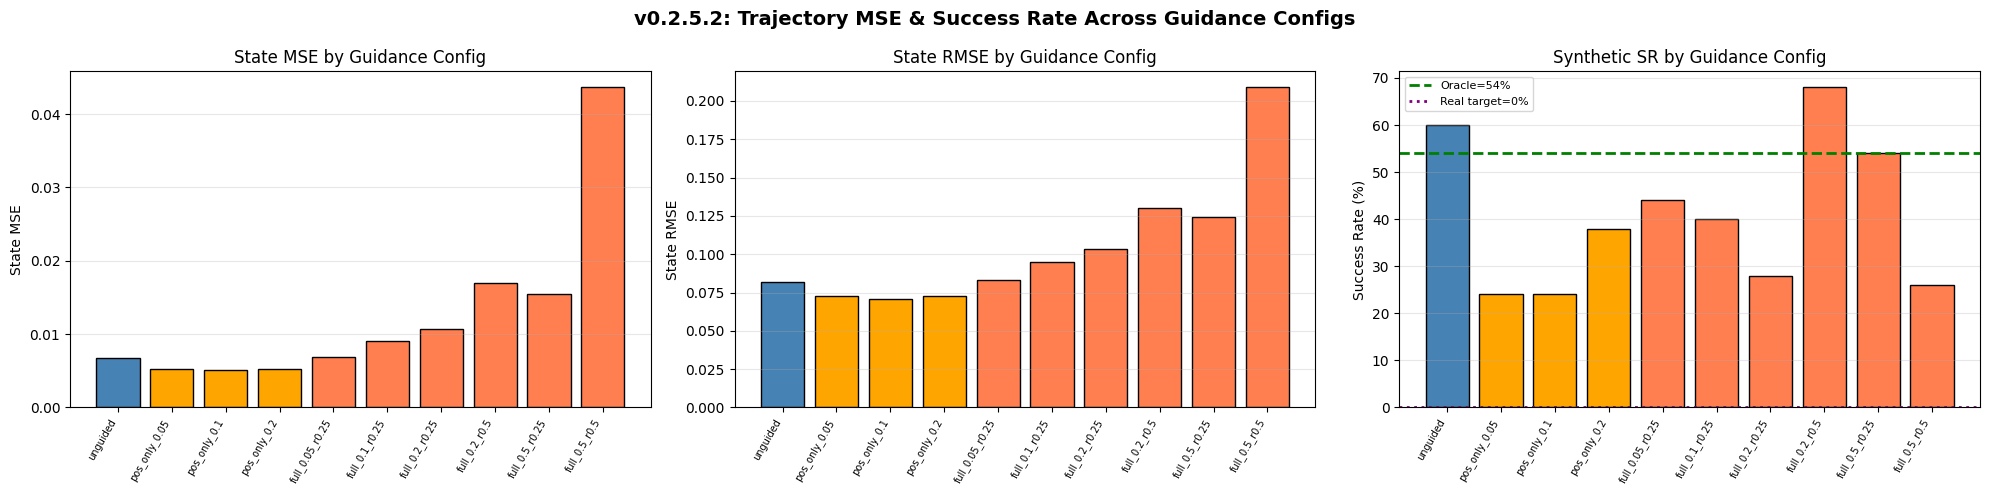

In [9]:
# ── Figure 1: State MSE by guidance config (bar chart) ──
labels = list(results_by_config.keys())
mses = [results_by_config[l]["state_mse"] for l in labels]
rmses = [results_by_config[l]["state_rmse"] for l in labels]
synth_srs = [results_by_config[l]["synth_sr"] * 100 for l in labels]

colors = []
for l in labels:
    if "unguided" in l:
        colors.append("steelblue")
    elif "pos_only" in l:
        colors.append("orange")
    else:
        colors.append("coral")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel 1: State MSE by config
axes[0].bar(range(len(labels)), mses, color=colors, edgecolor="black")
axes[0].set_xticks(range(len(labels)))
axes[0].set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
axes[0].set_ylabel("State MSE")
axes[0].set_title("State MSE by Guidance Config")
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: State RMSE by config
axes[1].bar(range(len(labels)), rmses, color=colors, edgecolor="black")
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
axes[1].set_ylabel("State RMSE")
axes[1].set_title("State RMSE by Guidance Config")
axes[1].grid(True, alpha=0.3, axis="y")

# Panel 3: Synthetic SR by config
axes[2].bar(range(len(labels)), synth_srs, color=colors, edgecolor="black")
axes[2].axhline(y=oracle_value * 100, color="green", linestyle="--", linewidth=2,
                label=f"Oracle={oracle_value*100:.0f}%")
axes[2].axhline(y=target_sr * 100, color="purple", linestyle=":", linewidth=2,
                label=f"Real target={target_sr*100:.0f}%")
axes[2].set_xticks(range(len(labels)))
axes[2].set_xticklabels(labels, rotation=60, ha="right", fontsize=7)
axes[2].set_ylabel("Success Rate (%)")
axes[2].set_title("Synthetic SR by Guidance Config")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle("v0.2.5.2: Trajectory MSE & Success Rate Across Guidance Configs", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

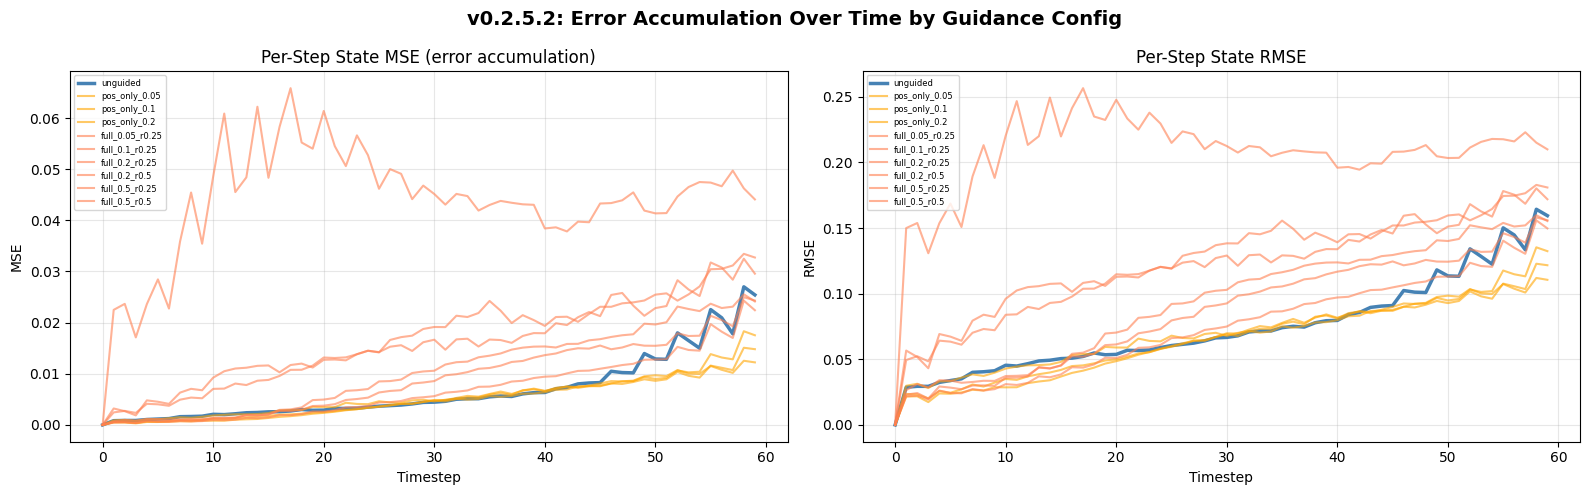

In [10]:
# ── Figure 2: Per-step MSE curves for all configs ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for label, r in results_by_config.items():
    color = "steelblue" if "unguided" in label else ("orange" if "pos_only" in label else "coral")
    alpha = 1.0 if "unguided" in label else 0.6
    lw = 2.5 if "unguided" in label else 1.5
    axes[0].plot(r["per_step_mse"], label=label, color=color, alpha=alpha, linewidth=lw)
    axes[1].plot(np.sqrt(r["per_step_mse"]), label=label, color=color, alpha=alpha, linewidth=lw)

axes[0].set_xlabel("Timestep")
axes[0].set_ylabel("MSE")
axes[0].set_title("Per-Step State MSE (error accumulation)")
axes[0].legend(fontsize=6, loc="upper left")
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Per-Step State RMSE")
axes[1].legend(fontsize=6, loc="upper left")
axes[1].grid(True, alpha=0.3)

plt.suptitle("v0.2.5.2: Error Accumulation Over Time by Guidance Config", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

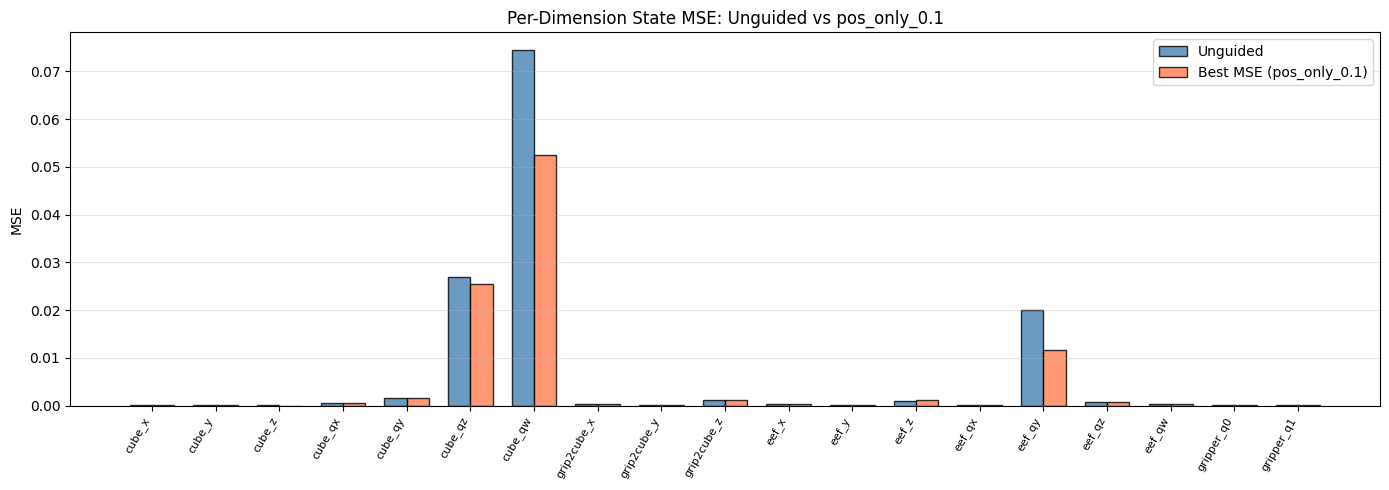

Best MSE config: pos_only_0.1 (MSE=0.005044)
Unguided MSE: 0.006732


In [11]:
# ── Figure 3: Per-dimension MSE bar chart (unguided vs best MSE config) ──
best_mse_label = min(results_by_config, key=lambda k: results_by_config[k]["state_mse"])
best_r = results_by_config[best_mse_label]
unguided_r = results_by_config["unguided"]

dim_labels = [DIM_NAMES[d] for d in range(STATE_DIM)]

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
x_pos = np.arange(STATE_DIM)
width = 0.35
ax.bar(x_pos - width/2, unguided_r["per_dim_mse"], width, color="steelblue", edgecolor="black",
       alpha=0.8, label="Unguided")
ax.bar(x_pos + width/2, best_r["per_dim_mse"], width, color="coral", edgecolor="black",
       alpha=0.8, label=f"Best MSE ({best_mse_label})")
ax.set_xticks(x_pos)
ax.set_xticklabels(dim_labels, rotation=60, ha="right", fontsize=8)
ax.set_ylabel("MSE")
ax.set_title(f"Per-Dimension State MSE: Unguided vs {best_mse_label}")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print(f"Best MSE config: {best_mse_label} (MSE={best_r['state_mse']:.6f})")
print(f"Unguided MSE: {unguided_r['state_mse']:.6f}")

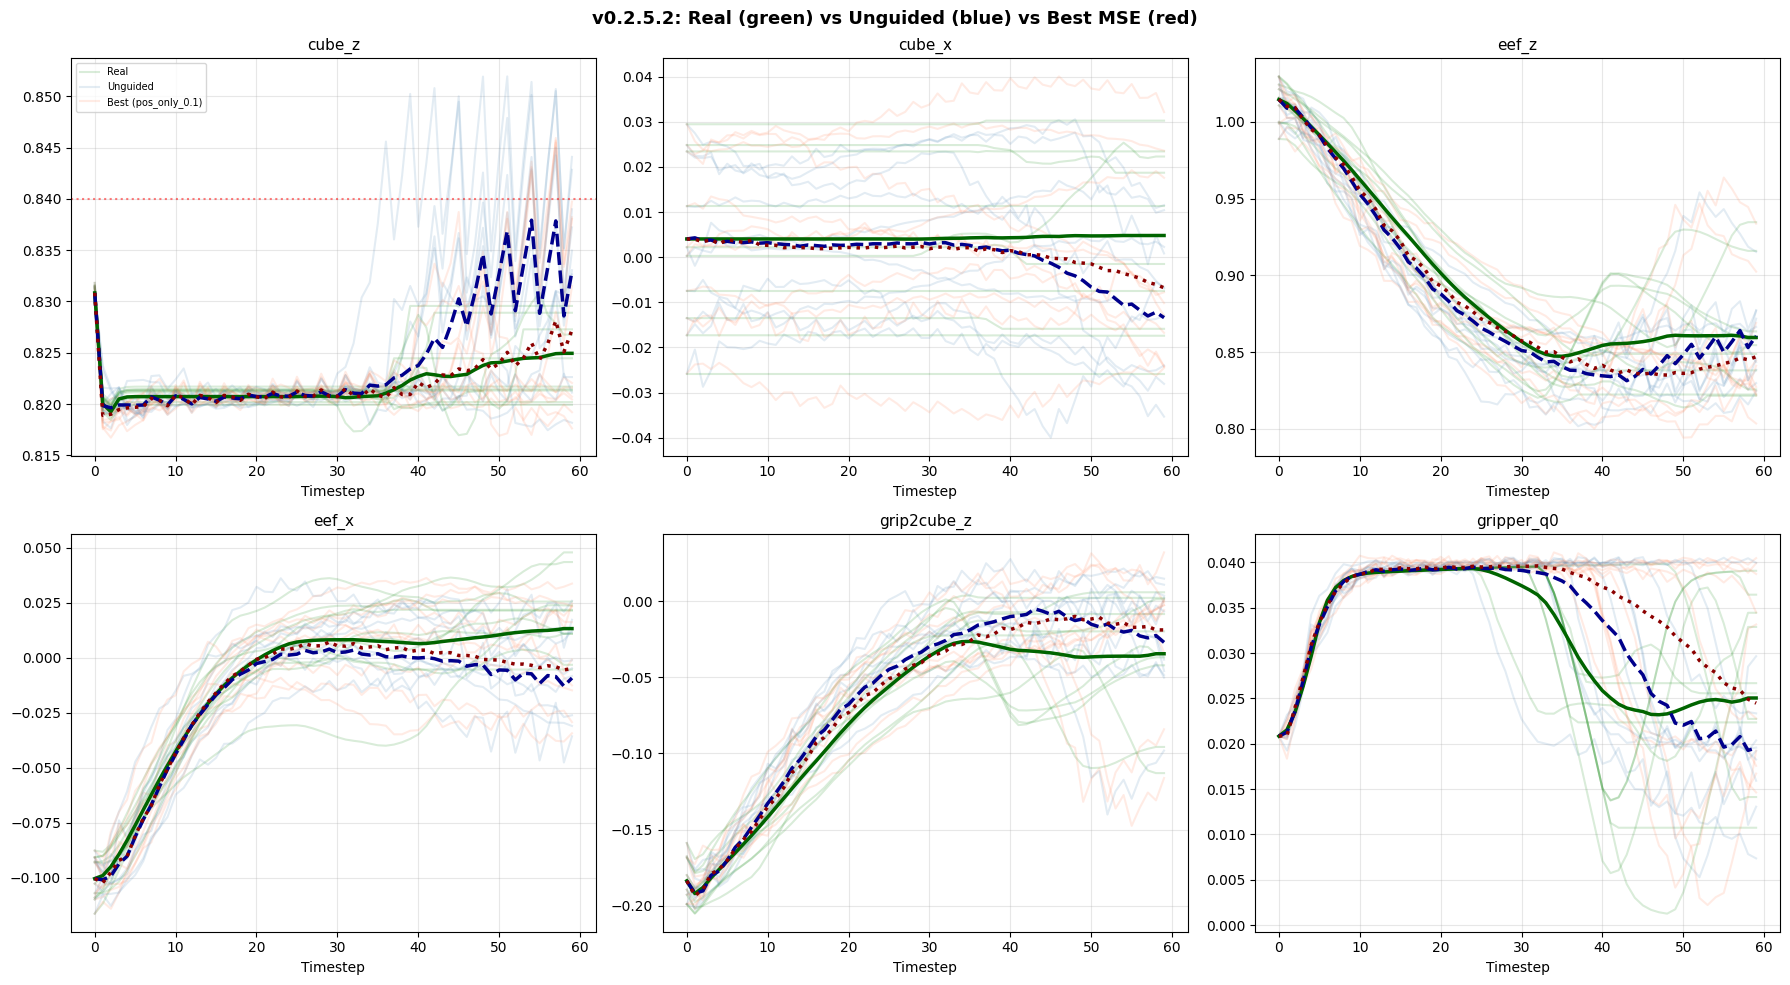

In [12]:
# ── Figure 4: Trajectory overlays — real vs unguided vs best MSE (key dims) ──
KEY_DIMS = {
    "cube_z": 2, "cube_x": 0, "eef_z": 12, "eef_x": 10,
    "grip2cube_z": 9, "gripper_q0": 17,
}

N_SHOW = 10
unguided_states = unguided_r["synth_states"]
best_states = best_r["synth_states"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, dim) in enumerate(KEY_DIMS.items()):
    ax = axes[idx]
    for j in range(min(N_SHOW, N_COMPARE)):
        ax.plot(real_states[j, :, dim], color="green", alpha=0.15,
                label="Real" if j == 0 else "")
        ax.plot(unguided_states[j, :, dim], color="steelblue", alpha=0.15,
                label="Unguided" if j == 0 else "")
        ax.plot(best_states[j, :, dim], color="coral", alpha=0.15,
                label=f"Best ({best_mse_label})" if j == 0 else "")
    # Mean trajectories
    ax.plot(real_states[:, :, dim].mean(axis=0), color="darkgreen", linewidth=2.5)
    ax.plot(unguided_states[:, :, dim].mean(axis=0), color="darkblue", linewidth=2.5, linestyle="--")
    ax.plot(best_states[:, :, dim].mean(axis=0), color="darkred", linewidth=2.5, linestyle=":")
    if dim == CUBE_Z_INDEX:
        ax.axhline(y=LIFT_THRESHOLD, color="red", linestyle=":", alpha=0.5)
    ax.set_title(f"{name}", fontsize=11)
    ax.set_xlabel("Timestep")
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, loc="upper left")

plt.suptitle("v0.2.5.2: Real (green) vs Unguided (blue) vs Best MSE (red)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

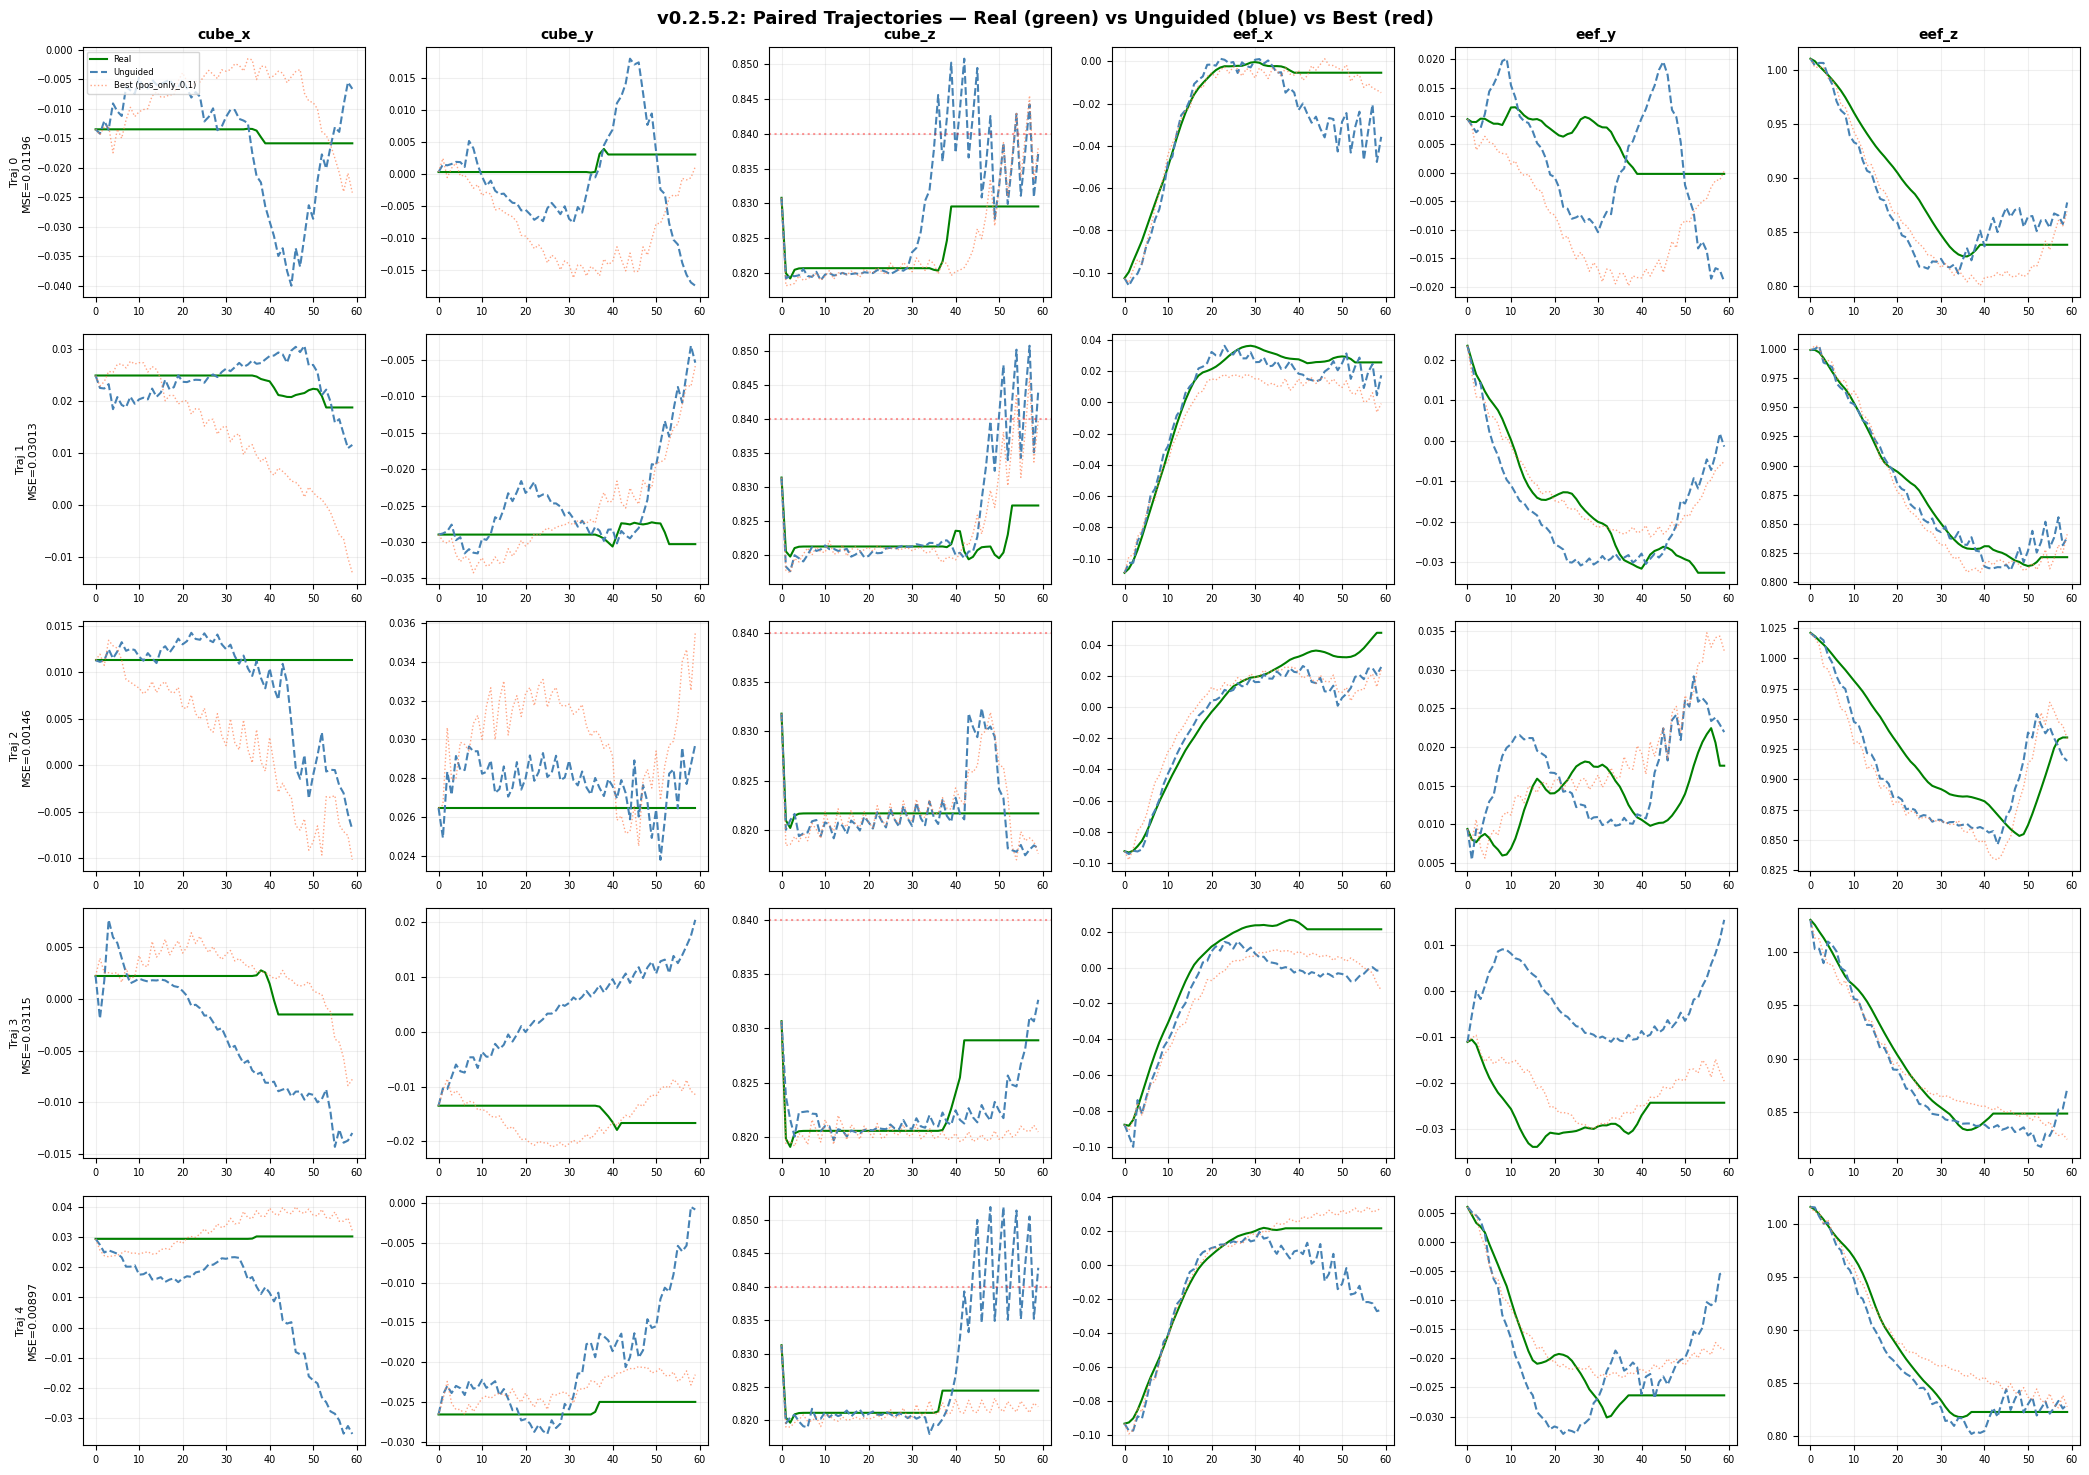

In [13]:
# ── Figure 5: Individual paired trajectories (5 pairs, unguided) ──
N_INDIV = 5
KEY_STATE_DIMS = {
    "cube_x": 0, "cube_y": 1, "cube_z": 2,
    "eef_x": 10, "eef_y": 11, "eef_z": 12,
}

fig, axes = plt.subplots(N_INDIV, len(KEY_STATE_DIMS), figsize=(3.5 * len(KEY_STATE_DIMS), 3 * N_INDIV))

for row in range(N_INDIV):
    traj_mse = unguided_r["per_traj_mse"][row]
    for col, (dim_name, dim_idx) in enumerate(KEY_STATE_DIMS.items()):
        ax = axes[row, col]
        ax.plot(real_states[row, :, dim_idx], color="green", linewidth=1.5, label="Real" if col == 0 else "")
        ax.plot(unguided_states[row, :, dim_idx], color="steelblue", linewidth=1.5, linestyle="--",
                label="Unguided" if col == 0 else "")
        ax.plot(best_states[row, :, dim_idx], color="coral", linewidth=1.0, linestyle=":",
                alpha=0.7, label=f"Best ({best_mse_label})" if col == 0 else "")
        
        if dim_idx == CUBE_Z_INDEX:
            ax.axhline(y=LIFT_THRESHOLD, color="red", linestyle=":", alpha=0.4)
        if row == 0:
            ax.set_title(dim_name, fontsize=10, fontweight="bold")
        if col == 0:
            ax.set_ylabel(f"Traj {row}\nMSE={traj_mse:.5f}", fontsize=8)
        ax.grid(True, alpha=0.2)
        ax.tick_params(labelsize=7)
        if row == 0 and col == 0:
            ax.legend(fontsize=6, loc="upper left")

plt.suptitle("v0.2.5.2: Paired Trajectories — Real (green) vs Unguided (blue) vs Best (red)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

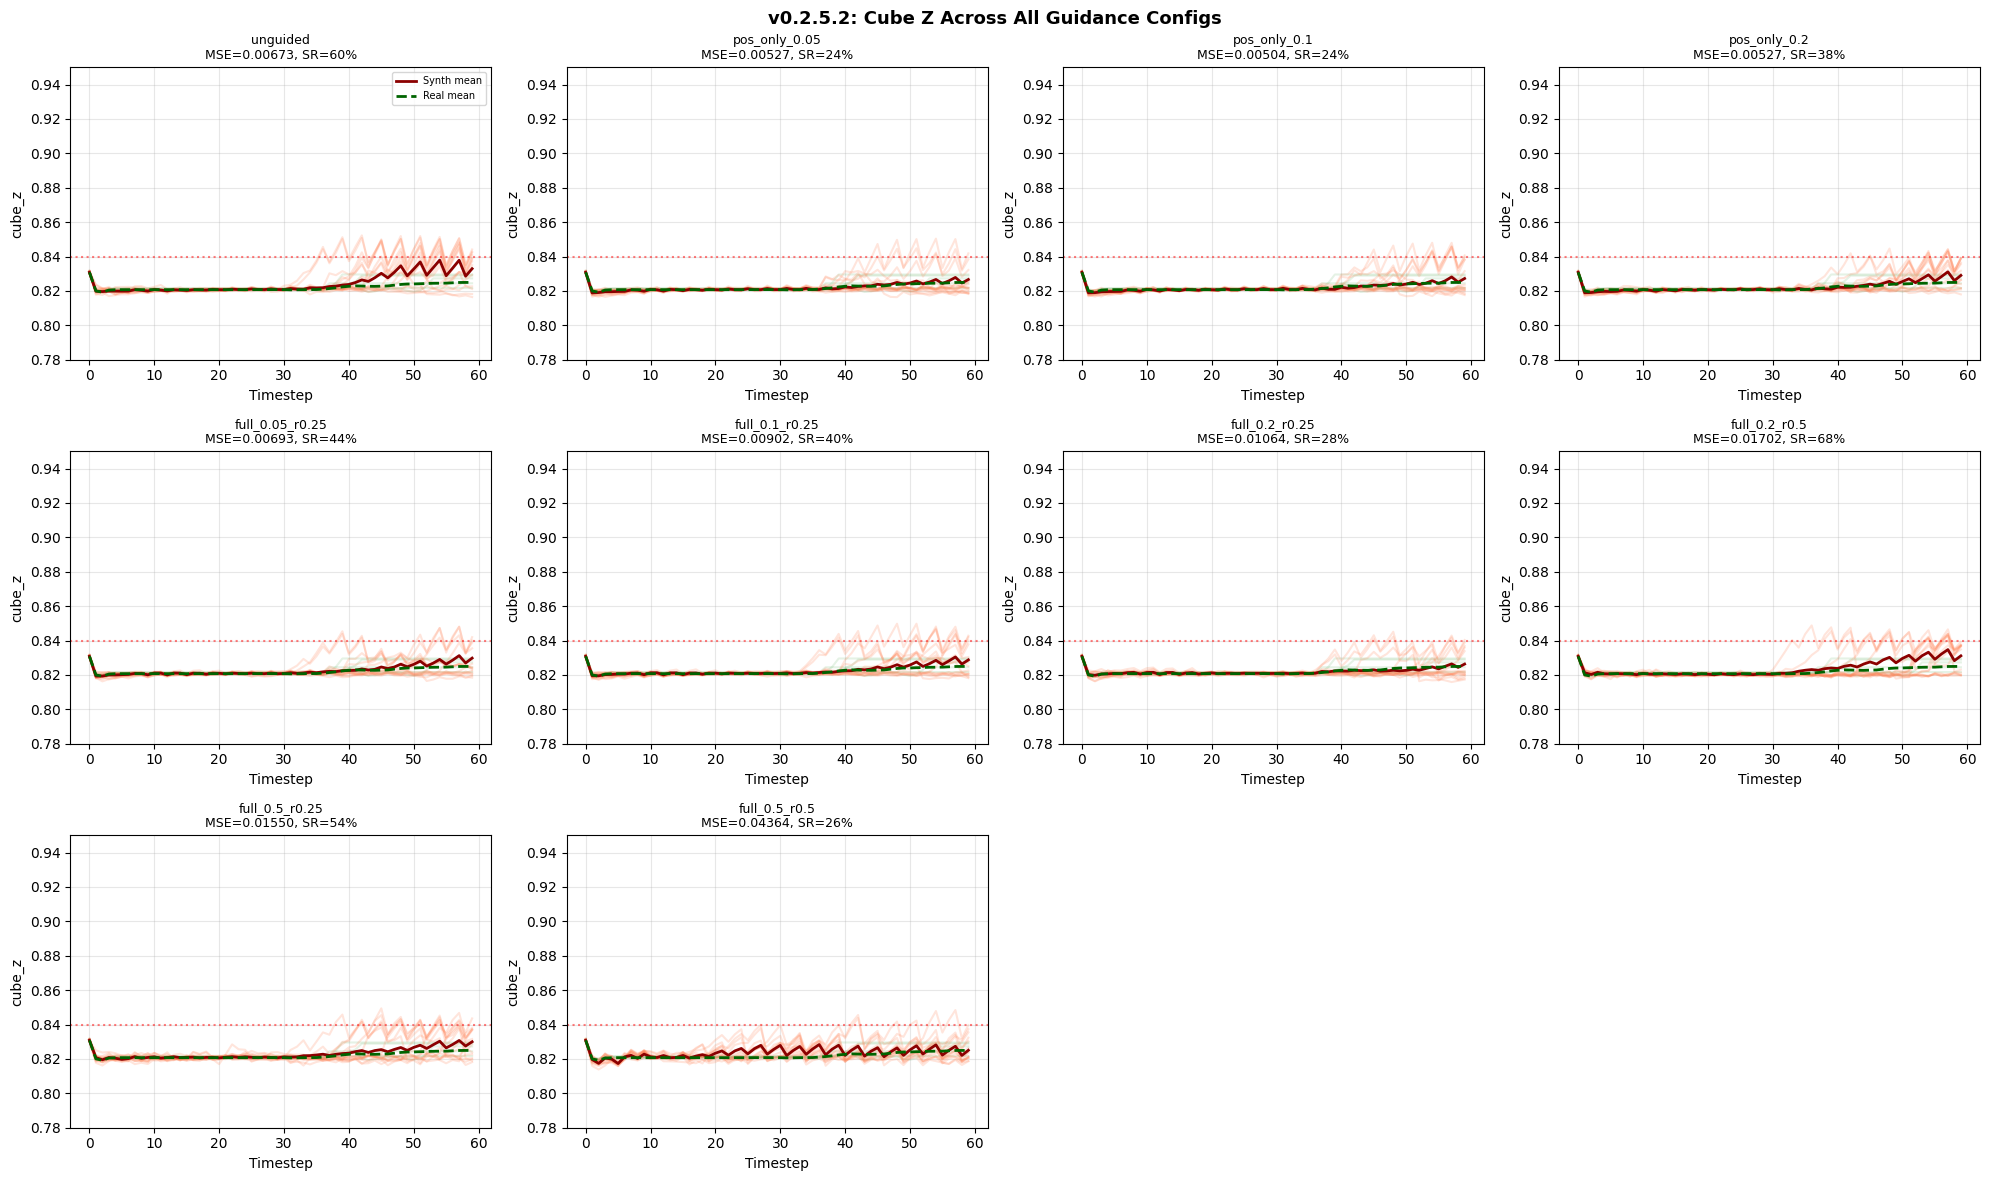

In [14]:
# ── Figure 6: Cube z across ALL configs (trajectory grid) ──
n_configs = len(results_by_config)
n_cols = 4
n_rows = math.ceil(n_configs / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for idx, (label, r) in enumerate(results_by_config.items()):
    ax = axes[idx]
    synth_s = r["synth_states"]
    for j in range(min(5, N_COMPARE)):
        ax.plot(real_states[j, :, CUBE_Z_INDEX], color="green", alpha=0.1)
    for j in range(min(15, N_COMPARE)):
        ax.plot(synth_s[j, :, CUBE_Z_INDEX], color="coral", alpha=0.2)
    ax.plot(synth_s[:, :, CUBE_Z_INDEX].mean(axis=0), color="darkred", linewidth=2, label="Synth mean")
    ax.plot(real_states[:, :, CUBE_Z_INDEX].mean(axis=0), color="darkgreen", linewidth=2,
            linestyle="--", label="Real mean")
    ax.axhline(y=LIFT_THRESHOLD, color="red", linestyle=":", alpha=0.5)
    ax.set_title(f"{label}\nMSE={r['state_mse']:.5f}, SR={r['synth_sr']*100:.0f}%", fontsize=9)
    ax.set_xlabel("Timestep")
    ax.set_ylabel("cube_z")
    ax.set_ylim([0.78, 0.95])
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7)

for idx in range(n_configs, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("v0.2.5.2: Cube Z Across All Guidance Configs", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

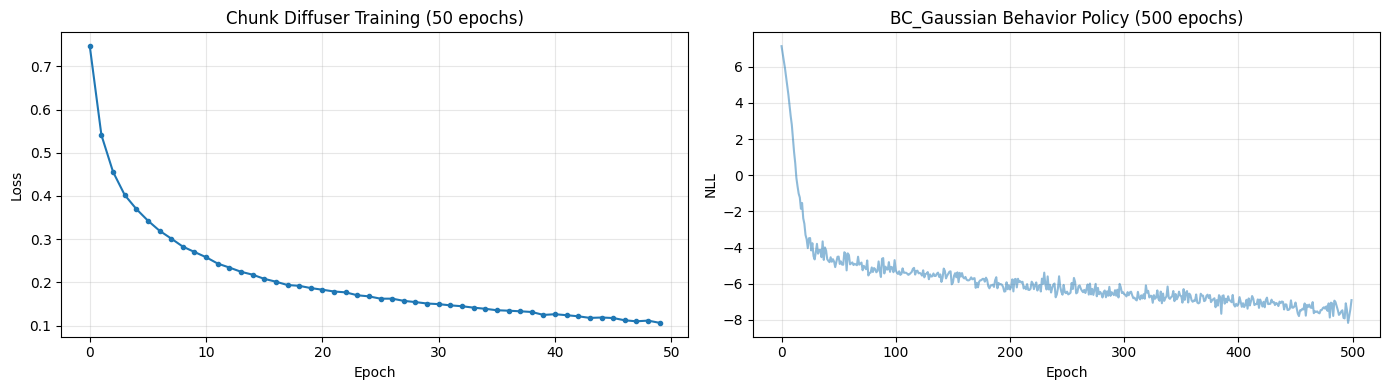

In [15]:
# ── Figure 7: Training curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epoch_losses, marker='o', markersize=3)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title(f"Chunk Diffuser Training ({TRAIN_EPOCHS} epochs)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(bc_losses, alpha=0.5)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("NLL")
axes[1].set_title(f"BC_Gaussian Behavior Policy ({BC_EPOCHS} epochs)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 7: Summary

In [16]:
# ── Marginal statistics for unguided ──
print(f"{'Dimension':<15} {'Real Mean':>10} {'Synth Mean':>11} {'Real Std':>10} {'Synth Std':>11} {'MSE':>10} {'RMSE':>10}")
print("-" * 80)
for d in range(STATE_DIM):
    r_mean = real_states[:, :, d].mean()
    s_mean = unguided_states[:, :, d].mean()
    r_std = real_states[:, :, d].std()
    s_std = unguided_states[:, :, d].std()
    mse = unguided_r["per_dim_mse"][d]
    rmse = np.sqrt(mse)
    print(f"{DIM_NAMES[d]:<15} {r_mean:>10.5f} {s_mean:>11.5f} {r_std:>10.5f} {s_std:>11.5f} {mse:>10.6f} {rmse:>10.6f}")

print(f"\n{'='*70}")
print(f"MVP v0.2.5.2 COMPLETE — Trajectory MSE Analysis")
print(f"{'='*70}")
print(f"Oracle V^pi = {oracle_value:.4f}, Real target SR = {target_sr*100:.1f}%")
print(f"\nBest MSE config: {best_mse_label}")
print(f"  State MSE = {best_r['state_mse']:.6f}, RMSE = {best_r['state_rmse']:.6f}")
print(f"  Synth SR = {best_r['synth_sr']*100:.1f}%")
print(f"\nUnguided:")
print(f"  State MSE = {unguided_r['state_mse']:.6f}, RMSE = {unguided_r['state_rmse']:.6f}")
print(f"  Synth SR = {unguided_r['synth_sr']*100:.1f}%")
print(f"\nAll configs initial state verification: ", end="")
all_ok = all(r["init_diff"] < 1e-4 for r in results_by_config.values())
print("ALL MATCH" if all_ok else "MISMATCH DETECTED")

Dimension        Real Mean  Synth Mean   Real Std   Synth Std        MSE       RMSE
--------------------------------------------------------------------------------
cube_x             0.00428     0.00001    0.01718     0.01777   0.000131   0.011449
cube_y             0.00285     0.00665    0.01590     0.01680   0.000078   0.008859
cube_z             0.82195     0.82426    0.00314     0.00750   0.000049   0.006985
cube_qx            0.00075    -0.00100    0.02170     0.00576   0.000496   0.022263
cube_qy            0.00287    -0.00165    0.03830     0.00638   0.001641   0.040511
cube_qz            0.64935     0.58639    0.29934     0.28309   0.026849   0.163858
cube_qw            0.16375     0.17163    0.67822     0.69038   0.074475   0.272901
grip2cube_x        0.01517     0.01858    0.03649     0.03524   0.000234   0.015302
grip2cube_y        0.00193     0.00297    0.01100     0.01003   0.000087   0.009332
grip2cube_z       -0.07406    -0.06151    0.05946     0.06265   0.001157   0.03